In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
df=pd.read_csv("E:\Data Analytics\AI\ExcelR\Logistic Regression\Employee Attrition Data.csv")

In [3]:
#Data Overview
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
#Data Overview
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [5]:
#Data Overview
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [6]:
#Data Overview
df.shape

(1470, 35)

## Data Preprocessing

In [7]:
# Handle Missing Values
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [8]:
# Encoding Categorical Variables 
df['Attrition'] = df['Attrition'].map({'Yes':1,'No':0})
df['Gender'] = df['Gender'].map({'Male':1, 'Female':0})
df = pd.get_dummies(df,columns=['BusinessTravel','Department','EducationField','JobRole',
                                'MaritalStatus','OverTime'],drop_first=True)

In [9]:
# Feature Selection
features = ['Age', 'JobSatisfaction', 'MonthlyIncome', 'YearsAtCompany',
            'Gender', 'TotalWorkingYears', 'NumCompaniesWorked', 'OverTime_Yes']
x = df[features]
y = df['Attrition']
df

,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,1,1,2,0,94,...,False,False,False,False,False,True,False,False,True,True
1,49,0,279,8,1,1,2,3,1,61,...,False,False,False,False,True,False,False,True,False,False
2,37,1,1373,2,2,1,4,4,1,92,...,True,False,False,False,False,False,False,False,True,True
3,33,0,1392,3,4,1,5,4,0,56,...,False,False,False,False,True,False,False,True,False,True
4,27,0,591,2,1,1,7,1,1,40,...,True,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,0,884,23,2,1,2061,3,1,41,...,True,False,False,False,False,False,False,True,False,False
1466,39,0,613,6,1,1,2062,4,1,42,...,False,False,False,False,False,False,False,True,False,False
1467,27,0,155,4,3,1,2064,2,1,87,...,False,False,True,False,False,False,False,True,False,True
1468,49,0,1023,2,3,1,2065,4,1,63,...,False,False,False,False,False,True,False,True,False,False


In [10]:
#Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(x)

In [11]:
X_scaled

array([[ 0.4463504 ,  1.15325359, -0.10834951, ..., -0.42164246,
         2.12513592,  1.59174553],
       [ 1.32236521, -0.66085318, -0.29171859, ..., -0.1645114 ,
        -0.67804939, -0.62824112],
       [ 0.008343  ,  0.2462002 , -0.93765369, ..., -0.55020799,
         1.32422583,  1.59174553],
       ...,
       [-1.08667552, -0.66085318, -0.07669019, ..., -0.67877352,
        -0.67804939,  1.59174553],
       [ 1.32236521, -0.66085318, -0.23647414, ...,  0.7354473 ,
        -0.27759435, -0.62824112],
       [-0.32016256,  0.2462002 , -0.44597809, ..., -0.67877352,
        -0.27759435, -0.62824112]], shape=(1470, 8))

In [12]:
#Train_Test Split
x_train, x_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

In [13]:
y_train

714     0
135     0
1271    1
477     0
806     0
       ..
1130    0
1294    0
860     1
1459    0
1126    0
Name: Attrition, Length: 1029, dtype: int64

In [14]:
# Model Building to train
log_model=LogisticRegression()

In [15]:
log_model.fit(x_train, y_train)

LogisticRegression()

## Model Evaluation

In [16]:
y_pred = log_model.predict(x_test)

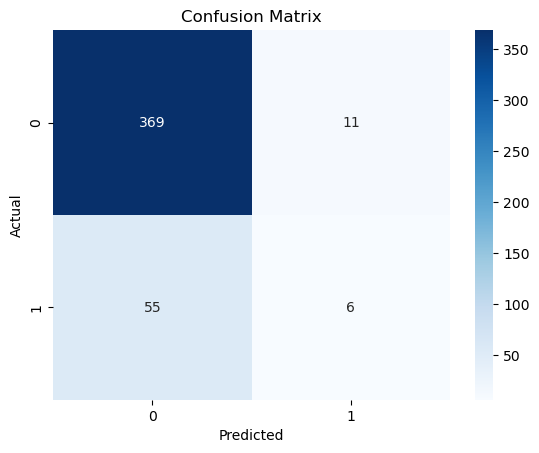

In [19]:
# Confusion Matrix
cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt ='d',cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [21]:
# Classification report
print(classification_report(y_test,y_pred))
print(f'Accuracy: {accuracy_score(y_test,y_pred)*100:.2f}')

              precision    recall  f1-score   support

           0       0.87      0.97      0.92       380
           1       0.35      0.10      0.15        61

    accuracy                           0.85       441
   macro avg       0.61      0.53      0.54       441
weighted avg       0.80      0.85      0.81       441

Accuracy: 85.03


In [24]:
# Feature Importance
feature_importance = pd.DataFrame({'Feature': features, 'Coefficient':log_model.coef_[0]})
feature_importance.sort_values(by='Coefficient',ascending=False,inplace=True)
feature_importance

,Feature,Coefficient
7,OverTime_Yes,0.722783
6,NumCompaniesWorked,0.440101
4,Gender,0.142979
3,YearsAtCompany,0.011970
2,MonthlyIncome,-0.191319
0,Age,-0.312473
1,JobSatisfaction,-0.324832
5,TotalWorkingYears,-0.559542


In [30]:
#Example unseen data point
ud = pd.DataFrame({
    'Age':[35],
    'JobSatisfaction':[4],
    'MonthlyIncome':[6500],
    'YearsAtCompany':[5],
    'Gender':[1],
    'TotalWorkingYears':[10],
    'NumCompaniesWorked':[2],
    'OverTime_Yes':[1]
})

#Scale the unseen data
ud_scaled=scaler.transform(ud)

#Prediction
ud_pred=log_model.predict(ud_scaled)
ud_prob=log_model.predict_proba(ud_scaled)

#Display results
print(f'Prediction for unseen data: {'Attrition' if ud_pred[0] == 1 else 'No Attrition'}')
print(f'Prediction probabilities: {ud_prob[0]}')

Prediction for unseen data: No Attrition
Prediction probabilities: [0.74932608 0.25067392]
